In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import gc
from scipy.stats import zscore
import copy
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
import scienceplots as sps
plt.style.use(['science', 'no-latex'])

In [2]:

def smooth_with_gaussian(data, sigma=3):
    return gaussian_filter1d(data, sigma=sigma, axis=1) 

def preprocess(data):   # This will receive (trials, time, neurons). Therefore mean across trials. 
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis = 0)
    std = np.std(data, axis = 0)
   
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    return data_z


In [3]:
file_numbers = [1, 2, 3,  4, 8, 14, 15, 20, 23]

structure = {file_number: {
    'left_attleft': [],
    'right_attleft': [],
    'left_attright': [],
    'right_attright': []
} for file_number in file_numbers} 

pearson_results = copy.deepcopy(structure)


total_time = time.time()
for file_number in  file_numbers:
    file_total = time.time()
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    load_data_start_time = time.time()
    data = pickle.load(open(file_path, 'rb'))
    elapsed_time = time.time() - load_data_start_time
    print(f"Dataset {file_number} loaded in {elapsed_time:.2f} seconds")


    attention_labels = data['label_attend'][0]
    label_left = data['label_left'][0]
    label_right = data['label_right'][0]
    attend_01 = data['attend'][0]
    omitted = data['omit'][0]
    trial_correct = data['trial_correct'][0]
    relevant = np.where((omitted == 0) & (trial_correct == 1))[0]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]

    num_trials, num_samples, num_neurons = left.shape
    num_neurons_attention = 80

    for j in range(0, num_trials):
        for i in range(0, num_neurons):
            count_left = np.count_nonzero(left[j, :, i] == 1)
            if count_left > 0:
                left[j, :, i] /= count_left
            count_right = np.count_nonzero(right[j, :, i] == 1)
            if count_right > 0:
                right[j, :, i] /= count_right

        for i in range(0, num_neurons_attention):
            count_attention = np.count_nonzero(att[j, :, i] == 1)
            if count_attention > 0:
                att[j, :, i] /= count_attention

    left = np.sum(left, axis=2)  # Return a single time series for the output
    right = np.sum(right, axis=2) 
    att = np.sum(att, axis=2)  

    left = preprocess(left)
    right = preprocess(right)
    att = preprocess(att)

    # Can now split into left and right attentional modality
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)


    #splitting left and right
    l_al = smooth_with_gaussian(left[left_indices], sigma = 2)
    r_al = smooth_with_gaussian(right[left_indices], sigma = 2)
    a_al = smooth_with_gaussian(att[left_indices], sigma = 2)

    l_ar = smooth_with_gaussian(left[right_indices], sigma = 2)
    r_ar = smooth_with_gaussian(right[right_indices], sigma = 2)
    a_ar = smooth_with_gaussian(att[right_indices], sigma = 2)

    print(l_al.shape[0])

    
    # Calculate Pearson correlation for each trial between l_al and a_al
    l_al_p = np.array([pearsonr(l_al[i], a_al[i])[0] for i in range(l_al.shape[0])])
    r_al_p = np.array([pearsonr(r_al[i], a_al[i])[0] for i in range(r_al.shape[0])])

    l_ar_p = np.array([pearsonr(l_ar[i], a_ar[i])[0] for i in range(l_ar.shape[0])])
    r_ar_p = np.array([pearsonr(r_ar[i], a_ar[i])[0] for i in range(r_ar.shape[0])])

    #-------collecting retults ---------
    pearson_results[file_number]['left_attleft'].append(l_al_p)
    pearson_results[file_number]['right_attleft'].append(r_al_p)
    pearson_results[file_number]['left_attright'].append(l_ar_p)
    pearson_results[file_number]['right_attright'].append(r_ar_p)


    del l_al, r_al, a_al, l_ar, r_ar, a_ar, data
    gc.collect()
    print(f'Dataset {file_number} complete in', time.time() - file_total)

print('total time elapsed =', time.time() - total_time)

Dataset 1 loaded in 28.68 seconds
328
Dataset 1 complete in 33.93546175956726
Dataset 2 loaded in 10.96 seconds
333
Dataset 2 complete in 15.360139846801758
Dataset 3 loaded in 6.95 seconds
329
Dataset 3 complete in 10.710936307907104
Dataset 4 loaded in 7.64 seconds
305
Dataset 4 complete in 11.500532627105713
Dataset 8 loaded in 8.22 seconds
339
Dataset 8 complete in 12.58743929862976
Dataset 14 loaded in 7.22 seconds
335
Dataset 14 complete in 11.142019748687744
Dataset 15 loaded in 8.10 seconds
318
Dataset 15 complete in 12.10422968864441
Dataset 20 loaded in 7.47 seconds
325
Dataset 20 complete in 11.274404525756836
Dataset 23 loaded in 6.80 seconds
328
Dataset 23 complete in 10.87307357788086
total time elapsed = 129.5075981616974


In [9]:
pearson_means = {
    'left_attleft': [],
    'right_attleft': [],
    'left_attright': [],
    'right_attright': []
}

pearson_errors = {
    'left_attleft': [],
    'right_attleft': [],
    'left_attright': [],
    'right_attright': []
}

# Take mean across trials for each dataset and store in the corresponding list
for file_number in file_numbers:
    for key in pearson_means.keys():
        mean_val = np.mean(pearson_results[file_number][key][0])
        pearson_means[key].append(mean_val)
        error_val = np.std(pearson_results[file_number][key][0]) / np.sqrt(len(pearson_results[file_number][key][0]))
        pearson_errors[key].append(error_val)

# Example: to get the "in" and "out" values for all datasets
in_vals = (np.array(pearson_means['left_attleft']) + np.array(pearson_means['right_attright'])) / 2
out_vals = (np.array(pearson_means['left_attright']) + np.array(pearson_means['right_attleft'])) / 2
# To combine standard errors for the average of two independent means,
# the correct formula is sqrt((err1**2 + err2**2) / 4)
# where err1 and err2 are the standard errors for each group.

in_errors = np.sqrt(
    (np.array(pearson_errors['left_attleft'])**2 + np.array(pearson_errors['right_attright'])**2) / 4
)
out_errors = np.sqrt(
    (np.array(pearson_errors['left_attright'])**2 + np.array(pearson_errors['right_attleft'])**2) / 4
)



In [10]:
print(in_vals)
print(out_vals)

print(in_errors)   
print(out_errors)

[0.3526354  0.34454096 0.29439021 0.38470362 0.29411185 0.37916212
 0.2041757  0.30494188 0.36021406]
[0.28551647 0.28991658 0.24295813 0.31967429 0.30213829 0.36046099
 0.23470812 0.29035171 0.28715451]
[0.0111902  0.01119052 0.01025305 0.01294659 0.01213122 0.01135688
 0.01058841 0.01242166 0.01018907]
[0.01172467 0.0109453  0.01111782 0.01406732 0.01204781 0.01216465
 0.01141145 0.01285462 0.01237789]


In [3]:
import numpy as np

In [5]:
in_vals = [0.3526354,  0.34454096, 0.38470362, 0.29411185, 0.37916212, 0.2041757, 0.30494188, 0.36021406, 0.29439021]
in_errors = [0.0111902,  0.01119052, 0.01025305, 0.01294659, 0.01213122, 0.01135688, 0.01058841, 0.01242166, 0.01018907]
out_vals = [0.28551647, 0.28991658, 0.31967429, 0.30213829, 0.36046099, 0.23470812, 0.29035171, 0.28715451, 0.24295813 ]
out_errors = [0.01172467, 0.0109453,  0.01111782, 0.01406732, 0.01204781, 0.01216465, 0.01141145, 0.01285462, 0.01237789]

in_mean = np.mean(in_vals)
out_mean = np.mean(out_vals)
in_error = np.sqrt(np.sum(np.array(in_errors)**2)) / len(in_errors)
out_error = np.sqrt(np.sum(np.array(out_errors)**2)) / len(out_errors)

print(f"Mean in: {in_mean:.4f} ± {in_error:.4f}")
print(f"Mean out: {out_mean:.4f} ± {out_error:.4f}")
from scipy.stats import ttest_rel

# in_vals and out_vals should be arrays of the same length
t_stat, p_val = ttest_rel(in_vals, out_vals)
print(f"Paired t-test: t = {t_stat:.4f}, p = {p_val:.4g}")

from numpy import arctanh
in_z = arctanh(in_vals)
out_z = arctanh(out_vals)
t_stat, p_val = ttest_rel(in_z, out_z)
print(f"Paired t-test (Fisher z): t = {t_stat:.4f}, p = {p_val:.4g}")


Mean in: 0.3243 ± 0.0038
Mean out: 0.2903 ± 0.0040
Paired t-test: t = 2.7689, p = 0.02434
Paired t-test (Fisher z): t = 2.8152, p = 0.02266


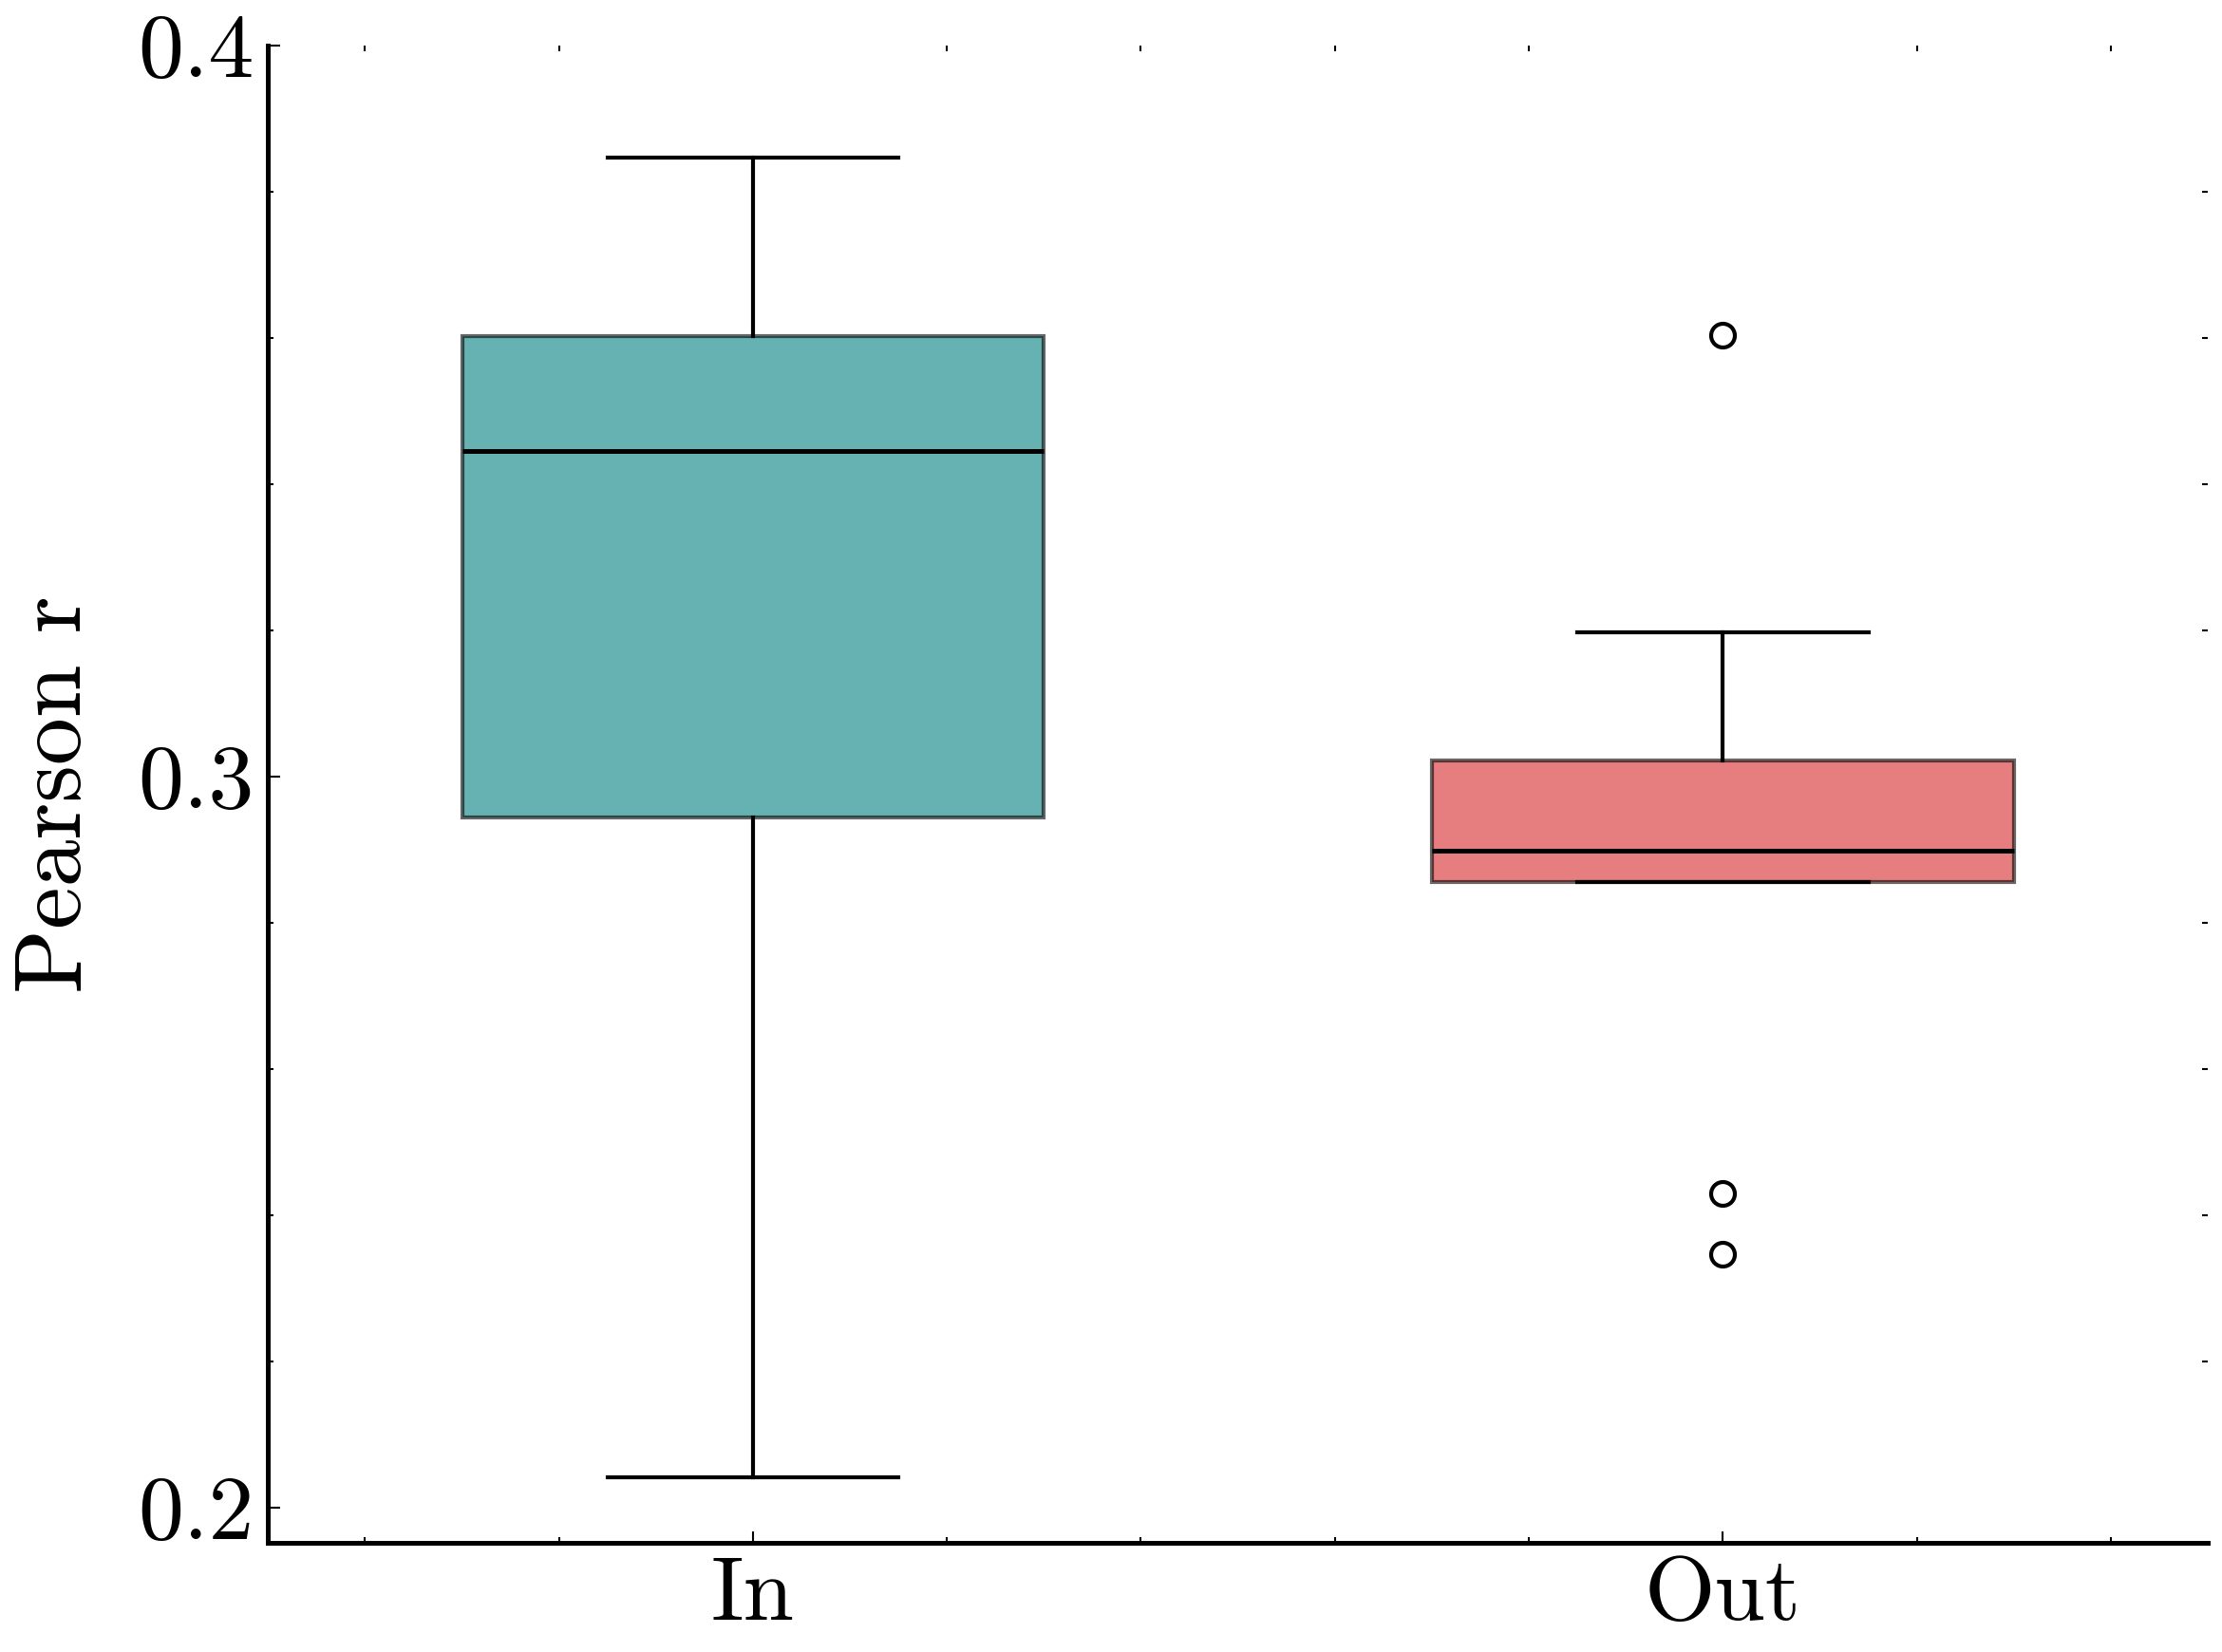

In [17]:
import matplotlib.pyplot as plt
# Adjust transparency of the colors
import matplotlib.pyplot as plt
# Adjust transparency of the colors
def plot_in_vs_out(in_vals, out_vals,
                   labels=('In','Out'),
                   ylabel='Pearson r'):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    # tell boxplot to draw filled boxes (patch_artist=True)
    bp = ax.boxplot([in_vals, out_vals],
                    widths=0.6,
                    notch=False,
                    patch_artist=True)
    
    # color sequence: C0 is blue, C1 is orange in the default Matplotlib cycle
    colors = ['teal', '#d62728']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # (optional) make whiskers/caps match box edge
    for element in ['whiskers','caps']:
        for line in bp[element]:
            line.set(color='k')
    
    #median line already black by default, but you can customize:
    for median in bp['medians']:
        median.set(color='k', linewidth=1.2)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=30)
    ax.set_ylabel(ylabel, fontsize=24, labelpad=10)
    # Minimal y-axis: min, mid, max
    ax.set_yticks([0.2, 0.3, 0.4])
    ax.set_yticklabels([0.2, 0.3, 0.4], fontsize=30)
    ax.tick_params(axis='both', labelsize=23)
    # Remove top and right axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    # Make axis lines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    # Increase x-axis padding
    ax.set_xlim(0.5, 2.5)
    plt.tight_layout()
    plt.show()

plot_in_vs_out(in_vals, out_vals,
               labels=('In','Out'),
               ylabel='Pearson r')

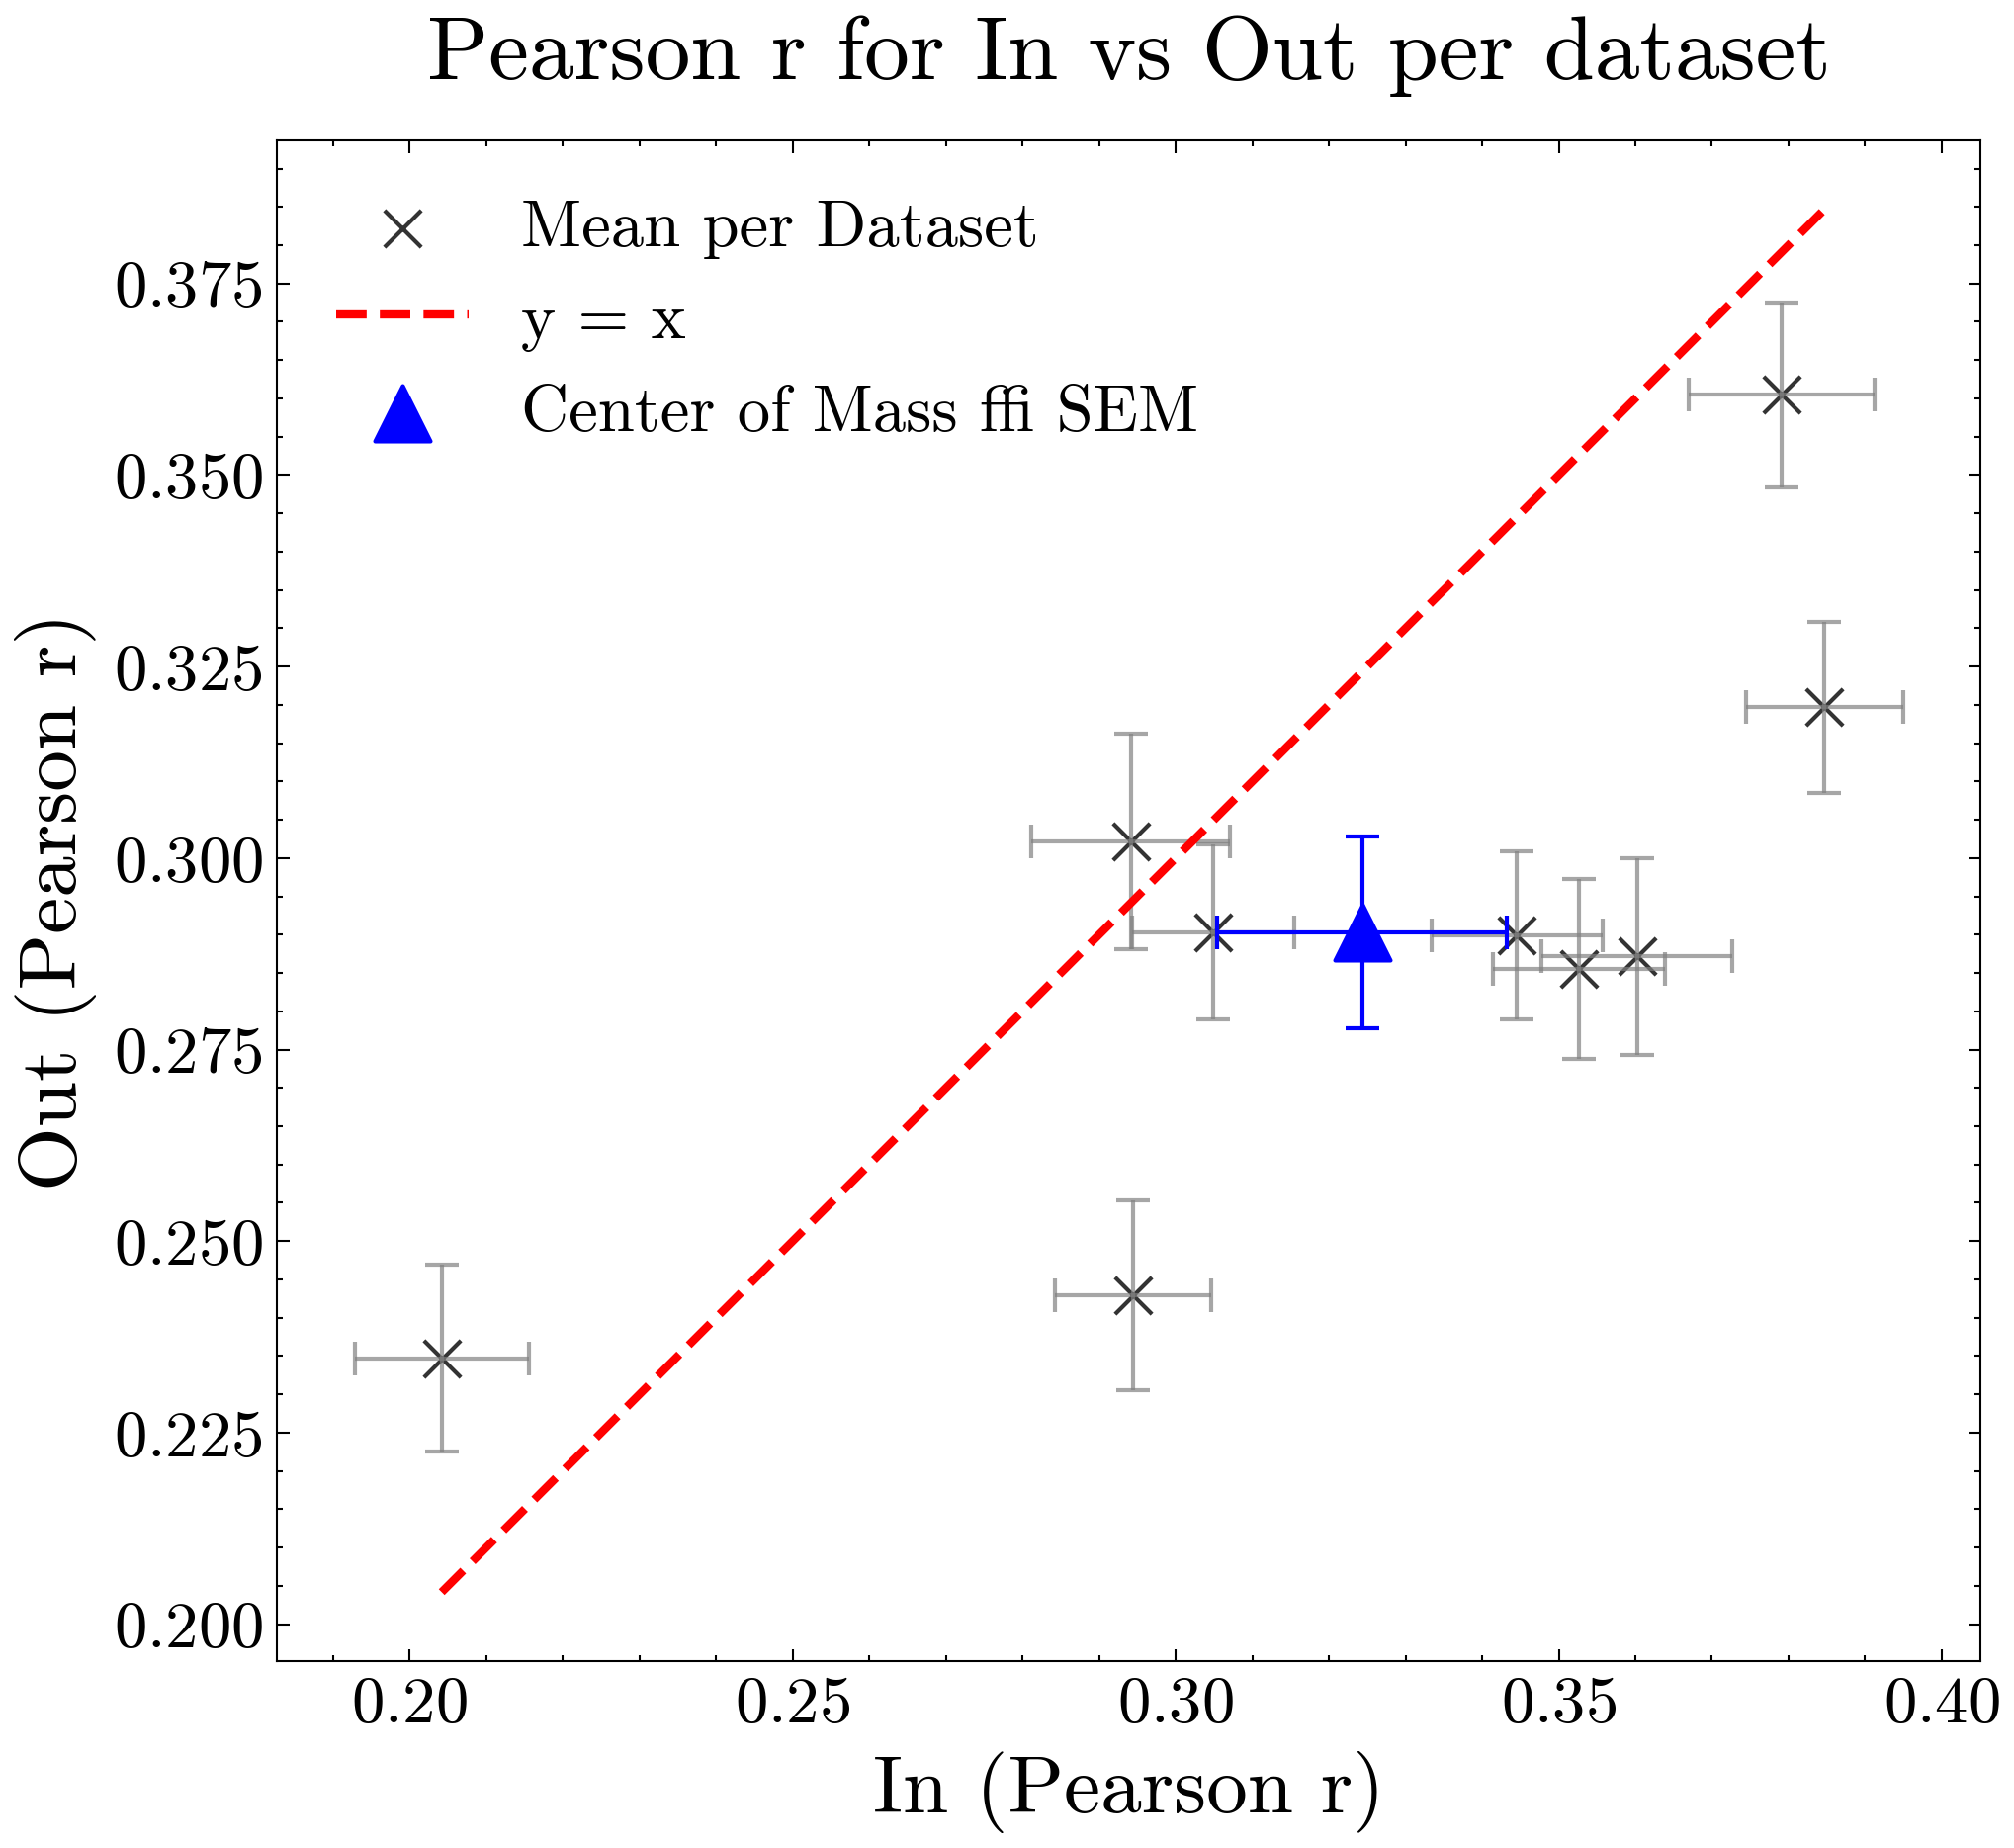

Paired t-test: t = 2.7689, p = 0.02434


TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [18]:
def plot_in_vs_out_scatter_with_com(in_vals, out_vals, in_errors=None, out_errors=None,
                                     ylabel='Out (Pearson r)', xlabel='In (Pearson r)', title=None):
    fig, ax = plt.subplots(figsize=(7, 7), dpi=300)
    # Scatter points
    ax.scatter(in_vals, out_vals, marker='x', color='k', s=80, alpha=0.8, label='Mean per Dataset')
    # Error bars if provided
    if in_errors is not None and out_errors is not None:
        ax.errorbar(in_vals, out_vals, xerr=in_errors, yerr=out_errors, fmt='none', ecolor='gray', alpha=0.7, capsize=4)
    # Diagonal reference line
    min_val = min(np.min(in_vals), np.min(out_vals))
    max_val = max(np.max(in_vals), np.max(out_vals))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='y = x')
    # Center of mass (mean of in and out)
    mean_in = np.mean(in_vals)
    mean_out = np.mean(out_vals)
    # Error of the mean (SEM)
    sem_in = np.std(in_vals, ddof=1) / np.sqrt(len(in_vals))
    sem_out = np.std(out_vals, ddof=1) / np.sqrt(len(out_vals))
    # Plot a blue 'x' for the center of mass with error bars
    ax.errorbar(mean_in, mean_out, xerr=sem_in, yerr=sem_out, fmt='', color='blue', capsize=4, zorder=10)
    ax.scatter(mean_in, mean_out, marker='^', color='blue', s=180, label='Center of Mass ± SEM', zorder=11)
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    if title:
        ax.set_title(title, fontsize=22, pad=15)
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(fontsize=16, loc='upper left')
    ax.set_aspect('equal', 'box')
    plt.tight_layout()
    plt.show()

plot_in_vs_out_scatter_with_com(
    in_vals, out_vals, in_errors, out_errors,
    ylabel='Out (Pearson r)', xlabel='In (Pearson r)',
    title='Pearson r for In vs Out per dataset'
)

from scipy.stats import ttest_rel

# Paired t-test for in_vals vs out_vals
t_stat, p_val = ttest_rel(in_vals, out_vals)
print(f"Paired t-test: t = {t_stat:.4f}, p = {p_val:.4g}")

# The t-test (ttest_rel) uses the paired sample means, not the SEM (errors).
# The errors (SEM) are for plotting, not for statistical testing.
# If you want to compare means with their SEM, you can report the difference and its SEM:
mean_diff = np.mean(in_vals - out_vals)
sem_diff = np.sqrt(np.mean(in_errors**2 + out_errors**2))
print(f"Mean difference: {mean_diff:.4f} ± {sem_diff:.4f} (mean ± SEM)")

In [3]:
import numpy as np
import scienceplots as sps
plt.style.use(['science', 'no-latex'])

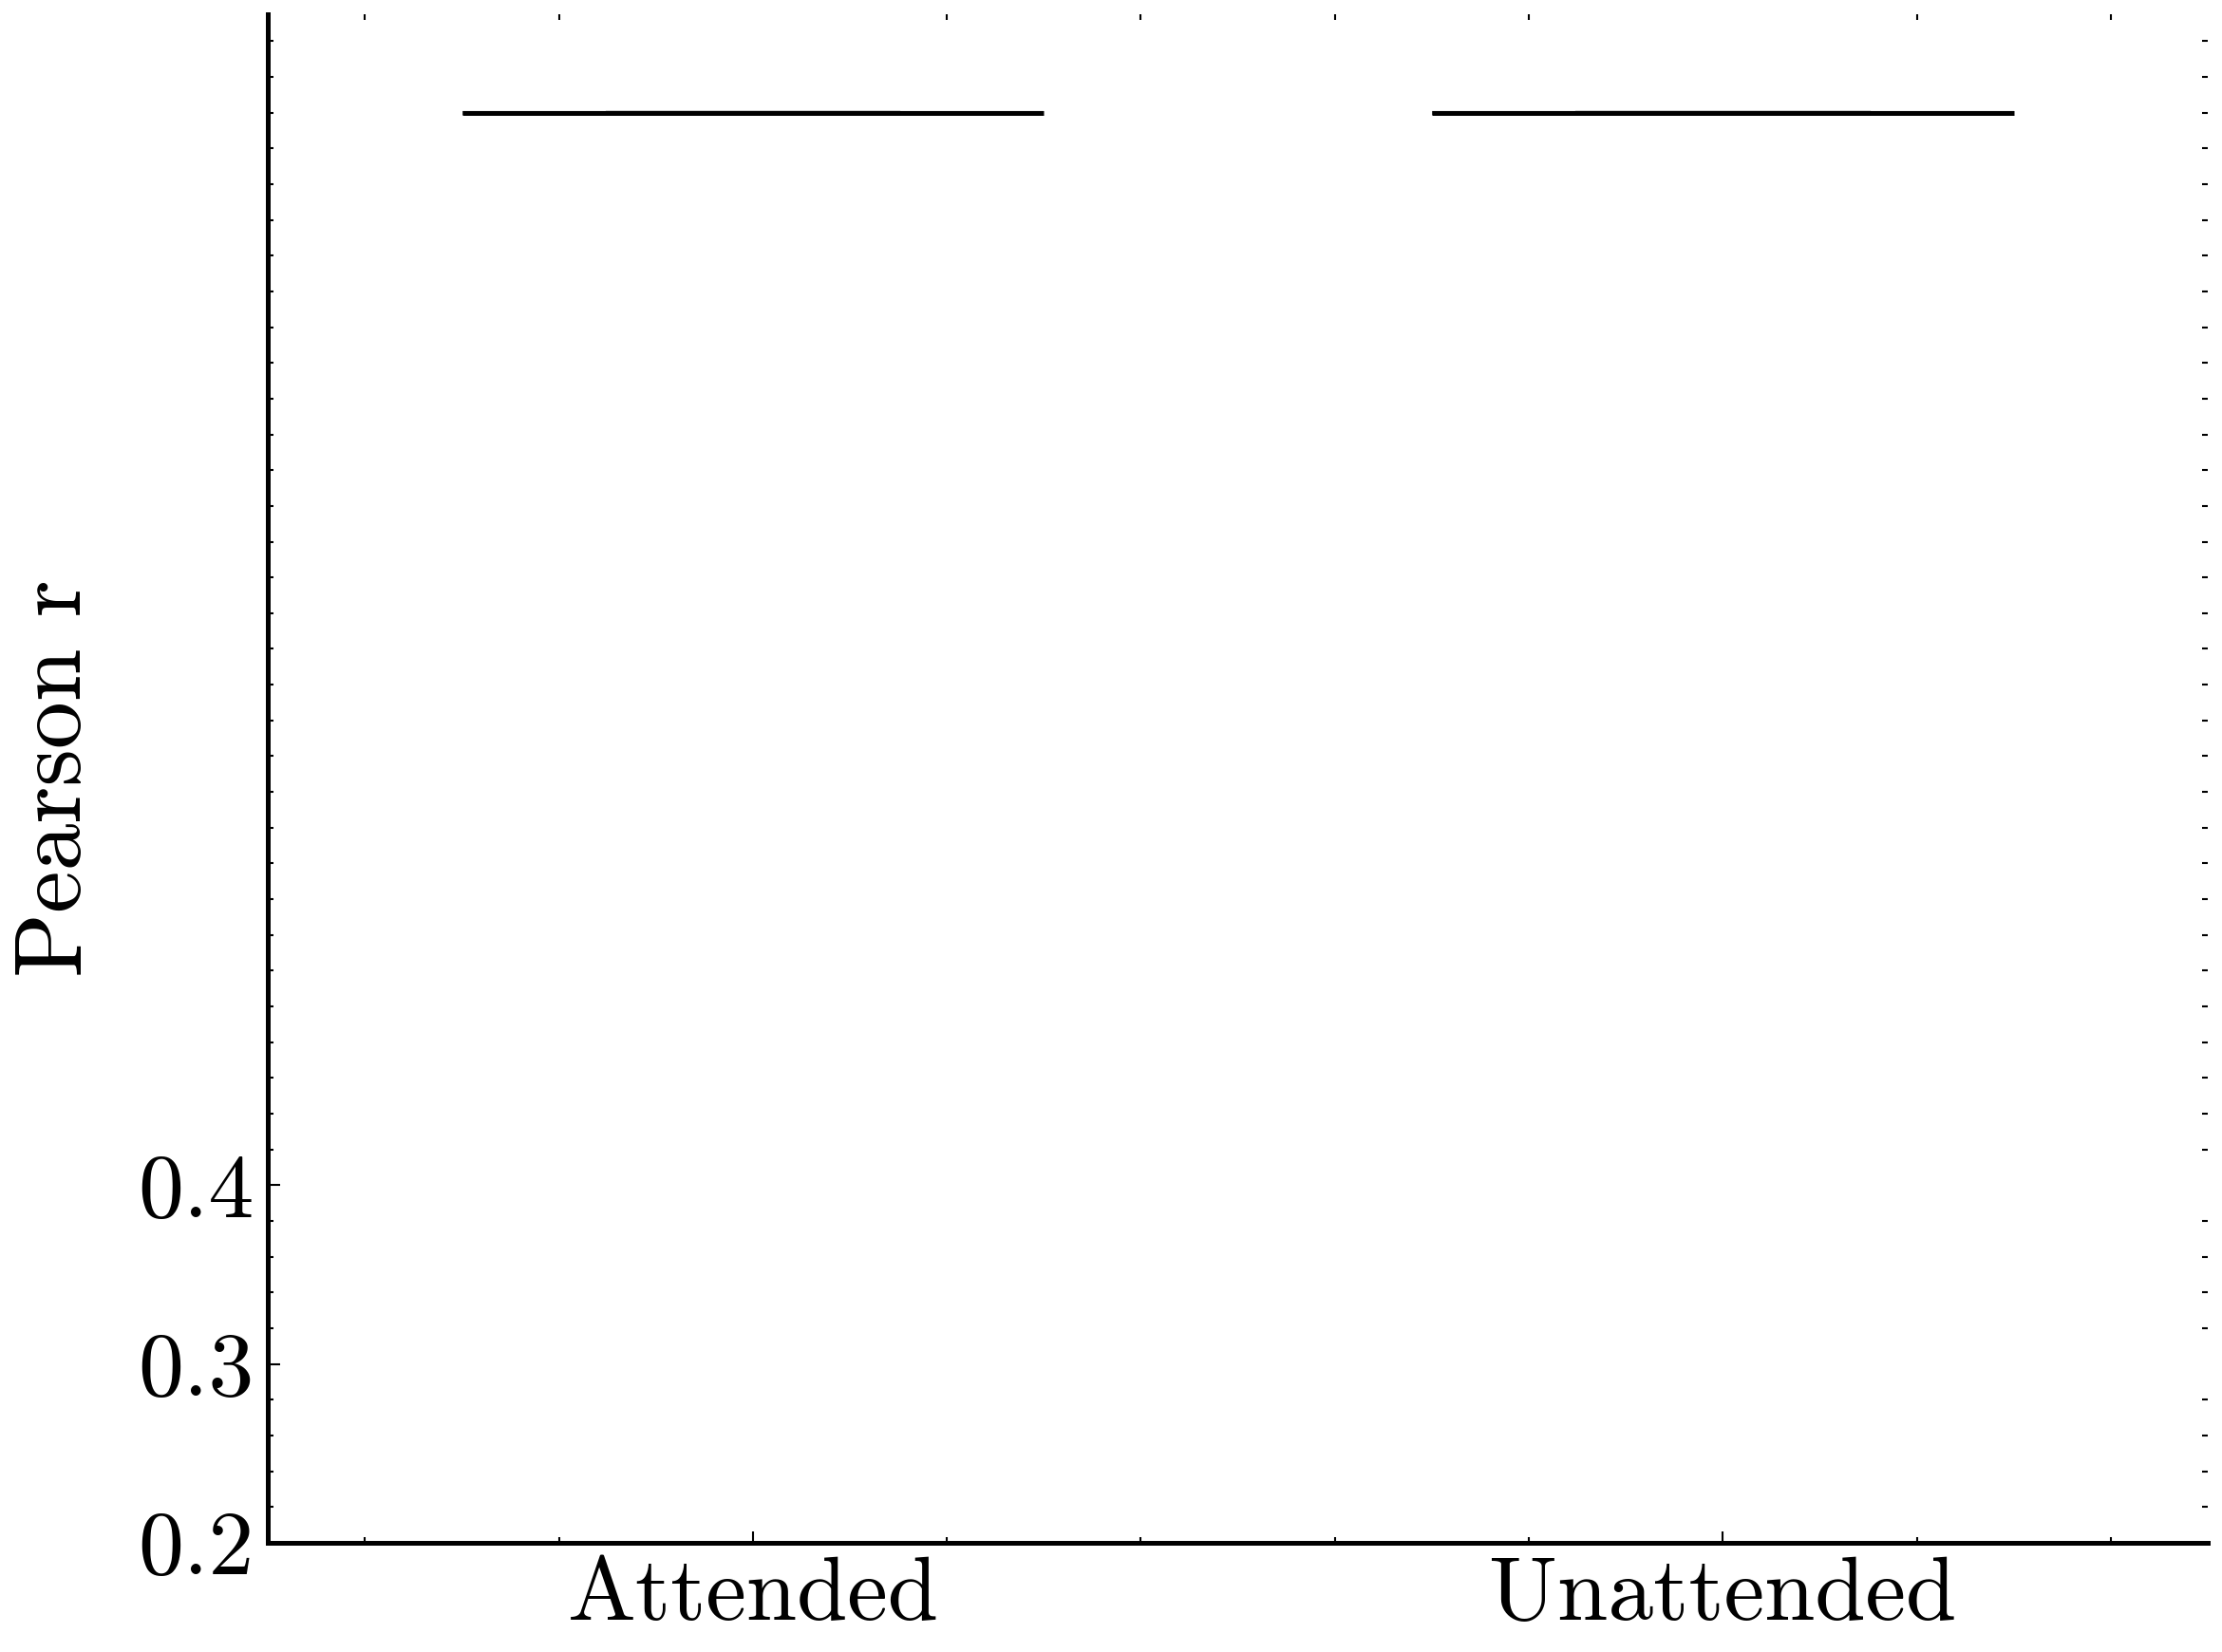

In [5]:
import matplotlib.pyplot as plt
# Adjust transparency of the colors
import matplotlib.pyplot as plt
# Adjust transparency of the colors
def plot_in_vs_out(in_vals, out_vals,
                   labels=('In','Out'),
                   ylabel='Pearson r'):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    # tell boxplot to draw filled boxes (patch_artist=True)
    bp = ax.boxplot([in_vals, out_vals],
                    widths=0.6,
                    notch=False,
                    patch_artist=True)
    
    # color sequence: C0 is blue, C1 is orange in the default Matplotlib cycle
    colors = ['teal', '#d62728']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # (optional) make whiskers/caps match box edge
    for element in ['whiskers','caps']:
        for line in bp[element]:
            line.set(color='k')
    
    #median line already black by default, but you can customize:
    for median in bp['medians']:
        median.set(color='k', linewidth=1.2)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=30)
    ax.set_ylabel(ylabel, fontsize=24, labelpad=10)
    # Minimal y-axis: min, mid, max
    ax.set_yticks([0.2, 0.3, 0.4])
    ax.set_yticklabels([0.2, 0.3, 0.4], fontsize=30)
    ax.tick_params(axis='both', labelsize=23)
    # Remove top and right axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    # Make axis lines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    # Increase x-axis padding
    ax.set_xlim(0.5, 2.5)
    plt.tight_layout()
    plt.show()

plot_in_vs_out([1], [1],
               labels=('Attended','Unattended'),
               ylabel='Pearson r')